In [1]:
METADATA = {
    'title': 'ACCESS Resource Provider Report',
    'version': 1,
    'description': 'Summary of resource data for ACCESS Resource Providers.',
    'history': [
        [ '1', '2025-07-17', 'Initial Version.']
    ]
}

In [18]:
# This cell contains imports for the python libraries used in the report
# and configures some library and error handling defaults

from datetime import datetime, timedelta, UTC
from IPython.display import display, Markdown, HTML
import inspect
import requests
import os
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import sys
import xdmod_data.themes
from xdmod_data.warehouse import DataWarehouse
from xdmod_data.report import header, footer, set_styles
from dotenv import load_dotenv
from os.path import expanduser
from pathlib import Path
import warnings
try:
    pd.set_option('future.no_silent_downcasting',True)
except pd.errors.OptionError:
    pass
pio.renderers.default = 'plotly_mimetype+notebook'
pio.templates.default = 'timeseries'
def custom_warning_handler(message, category, filename, lineno, file=None, line=None):
    if file is None:
        file = sys.stderr
    print(f'{message}', file=file)
warnings.showwarning = custom_warning_handler

In [20]:
# This cell contains function definitions for the various helper
# functions used by the notebook
# The functions assume that the following global variables are 
# defined:
#
# dw - DataWarehouse instance
# PROVIDER - str
# RESOURCES - dict containing the resource information
# TWO_YEARS_AGO_QUARTER_START_DATE - str start date for historical plots
# CURRENT_QUARTER_END_DATE - str end of the report period
# CURRENT_QUARTER_START_DATE - str start of the report period


def custom_warning_handler(message, category, filename, lineno, file=None, line=None):
    if file is None:
        file = sys.stderr
    print(f'{message}', file=file)


warnings.showwarning = custom_warning_handler


def get_quarter_dates(current_year, current_quarter):
    quarter_dates = []
    start_month = (current_quarter - 1) * 3 + 1
    y = current_year - 2
    m = start_month
    d = datetime(y, m, 1)
    still_going = True
    while still_going:
        if m == start_month and y == current_year:
            still_going = False
        if m == 10:
            y += 1
            m = 1
        else:
            m += 3
        start_date = d.strftime('%Y-%m-%d')
        d = datetime(y, m, 1)
        end_date = (d - timedelta(days=1)).strftime('%Y-%m-%d')
        quarter_dates.append([start_date, end_date])
    return quarter_dates


def get_resource_specs(resource_filter):
    with dw:
        resources = dw.get_resources(PROVIDER)

    result = {}
    for resource in resource_filter:
        atype = resources[resource]['allocation_type']
        result.setdefault(atype,[]).append(resource)
        
    return result


def two_year_line_plot_melt_and_plot(
    df,
    y,
):
    df = pd.melt(
        df,
        id_vars=['Date'],
        var_name='Resource',
        value_name=y,
    )
    plot = px.line(
        df,
        x='Date',
        y=y,
        title=f'{y} by Resource by Quarter, Last Two Years',
        color='Resource',
        markers=True,
    )
    plot.update_xaxes(
        dtick='M3',
    )
    plot.update_traces(
        hovertemplate='%{y:,.0f}',
    )
    plot.update_layout(
        xaxis_tickformat='Q%q %Y',
        yaxis_tickformat=',',
        hovermode='x unified',
        hoverlabel_namelength=-1,
    )
    plot.show()
    display(figure_caption(f'{y} by Resource by Quarter, Last Two Years'))


def two_year_line_plot_by_resource(
    jobs_metric,
    cloud_dimension,
    y,
):
    df = None
    with dw:
        if len(RESOURCES['Jobs']) > 0:
            tmp_df = dw.get_data(
                duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm='Jobs',
                metric=jobs_metric,
                dimension='Resource',
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={
                    'Service Provider': PROVIDER,
                },
            )
            tmp_df = tmp_df.reset_index(names='Date')
            if df is None:
                df = tmp_df
        if len(RESOURCES['Cloud']) > 0:
            tmp_df = pd.DataFrame()
            for resource in RESOURCES['Cloud']:
                project_counts = []
                tmp_df_inner = dw.get_data(
                    duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                    realm='Cloud',
                    metric='CPU Hours: Total',
                    dimension=cloud_dimension,
                    dataset_type='timeseries',
                    aggregation_unit='Quarter',
                    filters={
                        'Resource': resource,
                    },
                )
                tmp_df_inner_transposed = tmp_df_inner.transpose()
                for quarter in tmp_df_inner_transposed.columns:
                    project_counts.append(
                        len(tmp_df_inner_transposed[tmp_df_inner_transposed[quarter] > 0]),
                    )
                tmp_df[resource] = project_counts
            tmp_df.index = tmp_df_inner.index
            tmp_df = tmp_df.reset_index(names='Date')
            if df is None:
                df = tmp_df
    two_year_line_plot_melt_and_plot(df, y)


def two_year_line_plot_by_quarter(
    y=None,
    resource=None,
    dimension=None,
    nlargest=0,
    vertical_legend=False,
):
    if y == 'projects':
        metric = 'Number of Allocations: Active'
        metric_label = 'Number of Active Projects'
    elif y == 'users':
        metric = 'Number of Users: Active'
        metric_label = 'Number of Active Users'
    elif y == 'ace':
        metric = 'ACCESS Credit Equivalents Charged: Total (SU)'
        metric_label = 'ACCESS Credit Equivalents Charged'
    if resource == 'all':
        dimension = dimension_label = 'Resource'
        filters = {
            'Service Provider': PROVIDER,
        }
    else:
        filters = {
            'Resource': resource,
        }
    if dimension == 'pfos':
        dimension = 'Parent Science'
        dimension_label = 'Parent Field of Science'
    elif dimension == 'academic status':
        dimension = 'User NSF Status'
        dimension_label = 'User Academic Status'
    elif dimension == 'project':
        dimension = 'Allocation'
        dimension_label = 'Project'
    with dw:
        df = dw.get_data(
            duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
            realm=('Cloud' if len(RESOURCES['Cloud']) > 0 else 'Jobs'),
            metric=metric,
            dimension=dimension,
            dataset_type='timeseries',
            aggregation_unit='Quarter',
            filters=filters,
        )
    df = df.rename(
        columns={
            dimension: dimension_label,
        },
    )
    df = df.reset_index(names='Date')
    df = pd.melt(
        df,
        id_vars=['Date'],
        var_name=dimension_label,
        value_name=metric_label,
    )
    top_dimension_labels = None
    category_orders = None
    title = metric_label + (
        (f' on {resource}')
        if resource != 'all'
        else ''
    ) + f' by {dimension_label} by Quarter, Last Two Years'
    if nlargest > 0:
        top_dimension_labels = df[
            df['Date'] == CURRENT_QUARTER_START_DATE
        ].nlargest(
            nlargest,
            metric_label,
        )[dimension_label].tolist()
        df = df[df[dimension_label].isin(top_dimension_labels)]
        category_orders = {
            dimension_label: top_dimension_labels,
        }
        title += f', Top {nlargest}'
    plot = px.line(
        df,
        x='Date',
        y=metric_label,
        title=title,
        color=dimension_label,
        markers=True,
        category_orders=category_orders,
    )
    plot.update_traces(
        hovertemplate='%{y:,.0f}',
    )
    plot.update_layout(
        xaxis_tickformat='Q%q %Y',
        yaxis_tickformat=',',
        hovermode='x unified',
        hoverlabel_namelength=-1,
    )
    if vertical_legend:
        plot.update_layout(
            legend_orientation='v',
            legend_xanchor='left',
            legend_x=0,
            legend_yanchor='bottom',
            legend_y=-1.3,
        )
    plot.show()
    display(figure_caption(title))
    return top_dimension_labels


def make_performance_histogram(resource, device):

    if device == 'CPU':
        metric = 'CPU Hours: Total'
        dimension = 'CPU User Value'
    elif device == 'GPU':
        metric = 'GPU Hours: Total'
        dimension = 'GPU Usage Value'
        
    no_data = False
    try:
        with dw:
            cpu_user_histogram_df = dw.get_data(
                duration=(CURRENT_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm='SUPREMM',
                metric=metric,
                dimension=dimension,
                dataset_type='aggregate',
                filters={
                    'Resource': resource,
                },
            )
    except KeyError:
        no_data = True
    if no_data:
        display(HTML(f'''
<div class="warn">Performance histogram cannot be generated; data not available for {resource}.</div>
'''))
        return
    plot = px.bar(
        cpu_user_histogram_df,
        y=metric,
        title=f'{device} Usage by {dimension} on {resource}',
    )
    plot.update_traces(
        hovertemplate='%{x}<br>' + metric + ': <b>%{y:,.0f}</b>',
    )
    plot.show()
    display(figure_caption(
f'''Bar chart showing {device} Usage binned by {dimension} on {resource} for
compute jobs between {CURRENT_QUARTER_START_DATE} and {CURRENT_QUARTER_END_DATE}.
A value of NA indicates that no performance data was available for
the job. This typically happens with short running jobs or when
there is an issue with the data collection on the compute node'''))


def make_efficiency_plot(resource, device):

    if device == 'GPU':
        metrics = ['avg_percent_gpu_usage', 'gpu_time']
        avg_cpu_str = 'Avg GPU %: Idle: weighted by GPU hour'
        cpu_hours_str = 'GPU Hours: Total'
        units = 'GPU Hours'
    else:
        metrics = ['avg_percent_cpu_idle', 'wall_time']
        avg_cpu_str = 'Avg CPU %: Idle: weighted by core-hour'
        cpu_hours_str = 'CPU Hours: Total'
        units = 'Core Hours'

    efficiency_series = {}
    no_data = False
    try:
        with dw:
            for metric in metrics:
                efficiency_series[metric] = dw.get_data(
                    duration=(CURRENT_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                    realm='SUPREMM',
                    metric=metric,
                    dimension='User',
                    dataset_type='aggregate',
                    filters={
                        'Resource': resource,
                    },
                ).reset_index()
                if len(efficiency_series[metric]) == 0:
                    no_data = True
    except KeyError:
        no_data = True
    if no_data:
        display(HTML(f'''
<div class="warn">Efficiency plot cannot be generated; performance data not available for {resource}.</div>
'''))
        return
    cpu_usage_df = pd.merge(
        efficiency_series[metrics[0]],
        efficiency_series[metrics[1]],
        on='User',
        how='outer',
    ).dropna(how='any')

    top_cpu_hours_total = cpu_usage_df[cpu_hours_str].max()
    half_top_cpu_hours_total = 0.5 * top_cpu_hours_total
    cpu_usage_df['In First Quadrant'] = cpu_usage_df.apply(
        lambda row: row[avg_cpu_str] > 50 and row[cpu_hours_str] > half_top_cpu_hours_total,
        axis=1,
    )
    plot = px.scatter(
        cpu_usage_df,
        title=f'{device} Usage on {resource} by User',
        x=avg_cpu_str,
        y=cpu_hours_str,
        color='In First Quadrant',
        hover_data=['User'],
    )
    plot.add_vline(x=50, line_width=1)
    plot.add_hline(y=int(0.5 * top_cpu_hours_total), line_width=1)
    plot.update_layout(showlegend=False)
    hovertemplate = inspect.cleandoc(
        f"""
        <b>%{{customdata[0]}}</b><br>
        {avg_cpu_str}: <b>%{{x:.0f}} %</b><br>
        {cpu_hours_str}: <b>%{{y:,.0f}} {units}</b>
        <extra></extra>
        """,
    )
    plot.update_traces(hovertemplate=hovertemplate)
    plot.show()
    display(figure_caption(
f'''Scatter plot showing the average {device} Usage weighted by {device} hour
against {device} Hours for jobs by User on {resource}. All jobs with performance
data between {CURRENT_QUARTER_START_DATE} and {CURRENT_QUARTER_END_DATE} are included.
Data points in the top right of the chart indicate users who have high
resource usage with low average utilization'''))


def get_science_gateway_usage():
    try:
        with dw:
            df = dw.get_data(
                duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm='Gateways',
                metric='Number of Gateway Users: Active (Number of Users)',
                dimension='Resource',
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={
                    'Service Provider': PROVIDER,
                },
            )
            df = df.reset_index(names='Date')
        return df
    except KeyError:
        return None


def construct_cloud_df(dimension, reslist):
    df = pd.DataFrame()
    for resource in reslist:
        project_counts = []
        tmp_df = dw.get_data(
            duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
            realm='Cloud',
            metric='CPU Hours: Total',
            dimension=dimension,
            dataset_type='timeseries',
            aggregation_unit='Quarter',
            filters={
                'Resource': resource,
            },
        )
        tmp_df_transposed = tmp_df.transpose()
        for quarter in tmp_df_transposed.columns:
            project_counts.append(
                len(tmp_df_transposed[tmp_df_transposed[quarter] > 0]),
            )
        df[resource] = project_counts
    df.index = tmp_df.index
    return df


def get_report_data():
    REALMS = ['Jobs', 'Cloud']
    STATISTICS = ['projects', 'users']
    GROUP_BYS = ['all', 'pfos']
    dfs = {}
    resources = {}
    for realm in REALMS:
        dfs[realm] = {}
        resources[realm] = []
        for statistic in STATISTICS:
            dfs[realm][statistic] = {
                'all': {},
            }
    with dw:
        has_active_jobs = True
        try:
            jobs_resources_df = dw.get_data(
                duration=(CURRENT_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm='Jobs',
                metric='ACCESS Credit Equivalents Charged: Total (SU)',
                dimension='Resource',
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={
                    'Service Provider': PROVIDER,
                },
            )
        except KeyError:
            has_active_jobs = False
        if has_active_jobs:
            resources['Jobs'] = jobs_resources_df.columns.tolist()
            dfs['Jobs']['projects']['all']['all'] = dw.get_data(
                duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm='Jobs',
                metric='Number of Allocations: Active',
                dimension='Resource',
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={
                    'Service Provider': PROVIDER,
                },
            )
            for statistic in STATISTICS:
                for resource in ['all'] + resources['Jobs']:
                    dfs['Jobs'][statistic][resource] = {}
                    for group_by in GROUP_BYS:
                        if (
                            group_by == 'all' and resource != 'all'
                            or group_by != 'all' and resource == 'all'
                        ):
                            continue
                        if statistic == 'projects':
                            metric = 'Number of Allocations: Active'
                        elif statistic == 'users':
                            metric = 'Number of Users: Active'
                        elif statistic == 'ace':
                            metric = 'ACCESS Credit Equivalents Charged: Total (SU)'
                        if resource == 'all':
                            dimension = 'Resource'
                            filters = {
                                'Service Provider': PROVIDER,
                            }
                        else:
                            filters = {
                                'Resource': resource,
                            }
                        if group_by == 'pfos':
                            dimension = 'Parent Science'
                        elif group_by == 'academic status':
                            dimension = 'User NSF Status'
                        elif group_by == 'project':
                            dimension = 'Allocation'
                        dfs['Jobs'][statistic][resource][group_by] = dw.get_data(
                            duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                            realm='Jobs',
                            metric=metric,
                            dimension=dimension,
                            dataset_type='timeseries',
                            aggregation_unit='Quarter',
                            filters=filters,
                        )

    dfs['Cloud']['cpu hours'] = {
        'all': {},
    }
    with dw:
        has_active_cloud_vms = True
        try:
            jobs_resources_df = dw.get_data(
                duration=(CURRENT_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm='Cloud',
                metric='CPU Hours: Total',
                dimension='Resource',
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={
                    'Provider': PROVIDER,
                },
            )
        except KeyError:
            has_active_cloud_vms = False
        if has_active_cloud_vms:
            resources['Cloud'] = jobs_resources_df.columns.tolist()
            dfs['Cloud']['projects']['all']['all'] = construct_cloud_df('Allocation', resources['Cloud'])
            dfs['Cloud']['users']['all']['all'] = construct_cloud_df('User', resources['Cloud'])

    return dfs, resources


def summarize_usage(report_data, resources):
    top_5 = {'projects': {}}
    top_5_strings = {}
    for resource in resources['Jobs']:
        top_5['projects'][resource] = {
            'pfos': {},
        }
        top_5['projects'][resource]['pfos'] = report_data['Jobs']['projects'][resource]['pfos'].loc[CURRENT_QUARTER_START_DATE].nlargest(5)
        top_5_strings[resource] = []
        for pfos, count in top_5['projects'][resource]['pfos'].items():
            top_5_strings[resource].append(f'{pfos} ({int(count)} projects)')
    return top_5_strings


def get_ondemand_usage():
    try:
        with dw:
            df = dw.get_data(
                duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm='OnDemand',
                metric=('Number of Users: Active' if PROVIDER == 'SDSC' else 'Number of Known ACCESS Users: Active (Number of Users)'),
                dimension='Resource',
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={
                    'Service Provider': PROVIDER,
                },
            )
            df = df.reset_index(names='Date')
        return df

    except KeyError:
        return None

def get_cloud_utilization(resource):
    metrics = [
        ('Cloud', 'CPU Hours: Total', 'Used'),
        ('Resource Specifications', 'CPU Hours: Total', 'Available for ACCESS'),
        ('Resource Specifications', 'CPU Hours: Allocated', 'Resource Limit')
    ]

    data = []
    with dw:
        for (realm, metric, label) in metrics:
            data.append(dw.get_data(
                duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm=realm,
                metric=metric,
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={'Resource': [resource]},
            ).rename(columns = {metric: label}))

    return pd.concat(data, axis=1)

def plot_cloud_utilization(resource):
    
    data = get_cloud_utilization(resource)
    fig = px.line(data,
                  markers=True,
                  labels = {'value': 'CPU Hours', 'Metric': ''},
                  title=f'ACCESS Utilization of {resource}, Last Two Years')
    fig.update_xaxes(
        dtick='M3',
    )
    fig.update_traces(
        hovertemplate='%{y:,.0f}',
    )
    fig.update_layout(
        xaxis_tickformat='Q%q %Y',
        hovermode='x unified',
        hoverlabel_namelength=-1,
    )
    fig['data'][2]['line']['dash'] = 'dot'
    fig.show()
    display(figure_caption(f'''Usage of {resource} from {TWO_YEARS_AGO_QUARTER_START_DATE}
    to {CURRENT_QUARTER_END_DATE}. The red solid line shows the hypothetical upper bound 
    usage based on the number of compute elements on the resource. The green dotted line shows the mean value 
    of compute hours that the resource is obliged to make available for use by ACCESS allocated projects'''))


def get_jobs_utilization(resource):
    metrics = [
        ('Jobs', 'ACCESS Credit Equivalents Charged: Total (SU)'),
        ('Resource Specifications', 'ACCESS Credit Equivalents Available: Total (SU)'),
        ('Resource Specifications', 'ACCESS Credit Equivalents Available: Allocated (SU)')
    ]

    data = []
    with dw:
        for (realm, metric) in metrics:
            data.append(dw.get_data(
                duration=(TWO_YEARS_AGO_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE),
                realm=realm,
                metric=metric,
                dataset_type='timeseries',
                aggregation_unit='Quarter',
                filters={'Resource': [resource]},
            ))
            
    return pd.concat(data, axis=1).rename(columns = {'ACCESS Credit Equivalents Charged: Total (SU)': 'Used',
                                                     'ACCESS Credit Equivalents Available: Allocated (SU)': 'Available for ACCESS',
                                                     'ACCESS Credit Equivalents Available: Total (SU)': 'Resource Limit'})


def plot_jobs_utilization(resource):
    
    data = get_jobs_utilization(resource)
    fig = px.line(data,
                  markers=True,
                  labels = {'value': 'ACCESS Credit Equivalents', 'Metric': ''},
                  title=f'ACCESS Utilization of {resource}, Last Two Years')
    fig.update_xaxes(
        dtick='M3',
    )
    fig.update_traces(
        hovertemplate='%{y:,.0f}',
    )
    fig.update_layout(
        xaxis_tickformat='Q%q %Y',
        hovermode='x unified',
        hoverlabel_namelength=-1,
    )
    fig['data'][2]['line']['dash'] = 'dot'
    fig.show()
    display(figure_caption(f'''Usage of {resource} from {TWO_YEARS_AGO_QUARTER_START_DATE}
    to {CURRENT_QUARTER_END_DATE}. Usage is shown converted to ACCESS Credit Equivalents. 
    The red solid line shows the hypothetical upper bound for credit usage based on the 
    number of compute elements on the resource. The green dotted line shows the mean value 
    of the ACCESS Credits that the resource is obliged to make available for use by ACCESS
    allocated jobs'''))


SECTION_NUMBER = 0
SECTIONS = {}
FIGURE_NUMBER = 0


def figure_caption(caption):
    global FIGURE_NUMBER
    FIGURE_NUMBER += 1
    return Markdown(f'_Figure {SECTION_NUMBER}.{FIGURE_NUMBER} {caption}._\n&nbsp;\n')


def section_title(description):
    global SECTION_NUMBER
    global SECTIONS
    if description not in SECTIONS:
        SECTION_NUMBER += 1
        SECTIONS[description] = SECTION_NUMBER

    global FIGURE_NUMBER
    FIGURE_NUMBER = 0
    return Markdown(f'# {SECTIONS[description]}. {description}')

def plot_num_projects_by_type(resource):
    with dw:
        df=dw.get_data(
            realm='Jobs',
            dimension = 'Allocation',
            filters = {
                'Resource': resource,
                },
            duration = (TWO_YEARS_AGO_QUARTER_START_DATE, QUARTER_END_DATE),
            aggregation_unit='Quarter',
            metric = 'ACCESS Credit Equivalents Charged: Total (SU)'
        )

    list1 =df.columns.tolist()
    date_string_index = df.index.strftime('%Y-%m-%d').tolist()
    date_string_index.append(QUARTER_END_DATE)

    i=0
    while(i < 9):
        with dw:
           df2 =dw.get_raw_data(
               duration=(date_string_index[i],date_string_index[i+1]),
               realm='Allocations',
               fields = {'Name','Board Type'},
               filters = {'Resource': resource,}
            )
        filtered_df = df2[df2['Name'].isin(list1)].reset_index()
        filtered2_df = filtered_df.groupby(['Board Type']).count()
        filtered2_df = filtered2_df.reset_index()
        filtered2_df = filtered2_df.rename(columns={"Board Type": "Project Type", "Name": "Number of Active Projects"})
        filtered2_df = filtered2_df.drop(columns=['index'])
        filtered2_df.insert(0,"Date",date_string_index[i])
        if(i >= 1):
            filtered2_df = pd.concat([previous_df,filtered2_df])
        
        previous_df = filtered2_df
        i+=1
    create_plot(metric_label = 'Number of Active Projects', resource=resource, 
        dimension_label='Project Type', df=filtered2_df,vertical_legend = False,nlargest=0)




In [22]:
# The RP report is designed to be able to be generated interactively or via a shell script
# If run via a script then the process environment is used to configure the RP and time range
# or the report. For example:
#
# RP='PSC' YEAR=2025 QUARTER=2 jupyter nbconvert --execute --to html --no-input ACCESS-RP-Report.ipynb --output PSC-ACCESS-RP-Report-2025-Q2.html
#
# If running interactively, then you should this cell to set the PROVIDER, YEAR and QUARTER
# variables.

#PROVIDER = 'Purdue'
#PROVIDER = 'SDSC'
PROVIDER = 'PSC'
#PROVIDER = 'TACC'
#PROVIDER = 'NCSA'
#PROVIDER = 'TAMU'
#PROVIDER = 'StonyBrook'
#PROVIDER = 'UDEL'
#PROVIDER = 'IU - Indiana University'

YEAR = 2025
QUARTER = 2

# Enviroment will override settings (this is to support automatic scripted builds)
PROVIDER = os.getenv('RP', PROVIDER)
YEAR = int(os.getenv('YEAR', YEAR))
QUARTER = int(os.getenv('QUARTER', QUARTER))

REPORT_GENERATION_TIMESTAMP = datetime.now(UTC).strftime('%Y-%m-%dT%H:%M:%SZ')

In [24]:
# Load global variables needed for the report

QUARTER_DATES = get_quarter_dates(YEAR, QUARTER)
TWO_YEARS_AGO_QUARTER_START_DATE = QUARTER_DATES[0][0]
CURRENT_QUARTER_START_DATE, CURRENT_QUARTER_END_DATE = QUARTER_DATES[-1]

load_dotenv(Path(os.path.expanduser('~/xdmod-data.env')), override=True)
os.environ['XDMOD_API_TOKEN'] = os.environ['PROD_API_TOKEN']
dw = DataWarehouse('https://xdmod.access-ci.org')
dfs, RESOURCES = get_report_data()
top_5_strings = summarize_usage(dfs, RESOURCES)

In [25]:
# Introduction and data summary

display(set_styles())
display(header())

toc =  f'''# ACCESS Metrics Report for {PROVIDER}

Report template version {METADATA['version']} generated at {REPORT_GENERATION_TIMESTAMP}.

## Table of contents

1. [Introduction](#1.-Introduction)
2. [Resource Utilization](#2.-Resource-Utilization)
3. [Active Projects](#3.-Active-Projects)
4. [Active Users](#4.-Active-Users)
5. [Open OnDemand Usage](#5.-Open-OnDemand-Usage)
6. [Science Gateway Usage](#6.-Science-Gateway-Usage)
7. [Network Flows](#7.-Network-Flows)
'''

if len(RESOURCES['Jobs']) > 0:
    toc += '8. [Job Performance](#8.-Job-Performance)'

display(Markdown(toc))
display(section_title('Introduction'))
display(Markdown(
    f'''This report from the ACCESS Metrics team contains information about the utilization and performance of the resources
    from the Resource Provider **{PROVIDER}**
    for the dates {CURRENT_QUARTER_START_DATE} through {CURRENT_QUARTER_END_DATE}.
    The data in this report come from [ACCESS XDMoD](https://xdmod.access-ci.org) via the ACCESS Central Database as well as data provided directly to the
    ACCESS Metrics team by the Resource Provider.
    You can contact the ACCESS Metrics team regarding the data in this report by [submitting a ticket](https://support.access-ci.org/help-ticket).
    Below is a summary of the data for each active resource during this time period.
    '''
))
if len(RESOURCES['Jobs']) > 0:
    display(Markdown('### Compute Resources'))
    for resource in RESOURCES['Jobs']:
        display(Markdown(f'#### {resource}'))
        display(Markdown(
            f'''- There were **{int(dfs['Jobs']['projects']['all']['all'].at[CURRENT_QUARTER_START_DATE, resource]):,} active projects**
            (projects that ran at least one job).
            \n- There were **{int(dfs['Jobs']['users']['all']['all'].at[CURRENT_QUARTER_START_DATE, resource]):,} active users**
            (users who ran at least one job).
            \n- The top 5 parent fields of science in terms of number of active projects were:
            '''
            + ''.join([f'\n\n    - **{string}**' for string in top_5_strings[resource]])
        ))
if len(RESOURCES['Cloud']) > 0:
    display(Markdown('### Cloud Resources'))
    for resource in RESOURCES['Cloud']:
        display(Markdown(f'#### {resource}'))
        display(Markdown(
            f'''- There were **{int(dfs['Cloud']['projects']['all']['all'].at[CURRENT_QUARTER_START_DATE, resource]):,} active projects**
            (projects that ran at least one cloud virtual machine).
            \n- There were **{int(dfs['Cloud']['users']['all']['all'].at[CURRENT_QUARTER_START_DATE, resource]):,} active users**
            (users that ran at least one cloud virtual machine).
            '''
        ))

# ACCESS Metrics Report for PSC

Report template version 1 generated at 2025-08-14T20:10:52Z.

## Table of contents

1. [Introduction](#1.-Introduction)
2. [Resource Utilization](#2.-Resource-Utilization)
3. [Active Projects](#3.-Active-Projects)
4. [Active Users](#4.-Active-Users)
5. [Open OnDemand Usage](#5.-Open-OnDemand-Usage)
6. [Science Gateway Usage](#6.-Science-Gateway-Usage)
7. [Network Flows](#7.-Network-Flows)
8. [Job Performance](#8.-Job-Performance)

# 1. Introduction

This report from the ACCESS Metrics team contains information about the utilization and performance of the resources
    from the Resource Provider **PSC**
    for the dates 2025-04-01 through 2025-06-30.
    The data in this report come from [ACCESS XDMoD](https://xdmod.access-ci.org) via the ACCESS Central Database as well as data provided directly to the
    ACCESS Metrics team by the Resource Provider.
    You can contact the ACCESS Metrics team regarding the data in this report by [submitting a ticket](https://support.access-ci.org/help-ticket).
    Below is a summary of the data for each active resource during this time period.
    

### Compute Resources

#### Bridges 2 RM

...

- There were **4 active projects**
            (projects that ran at least one job).
            
- There were **11 active users**
            (users who ran at least one job).
            
- The top 5 parent fields of science in terms of number of active projects were:
            

    - **Computer and Information Sciences (3 projects)**

    - **Other (1 projects)**

    - **Biological Sciences (0 projects)**

#### Bridges2 GPU AI

- There were **2 active projects**
            (projects that ran at least one job).
            
- There were **2 active users**
            (users who ran at least one job).
            
- The top 5 parent fields of science in terms of number of active projects were:
            

    - **Computer and Information Sciences (1 projects)**

    - **Earth and Environmental Sciences (1 projects)**

    - **Physical Sciences (0 projects)**

    - **Engineering and Technology (0 projects)**

    - **Mathematics (0 projects)**

#### PSC Neocortex SDFlex

- There were **3 active projects**
            (projects that ran at least one job).
            
- There were **24 active users**
            (users who ran at least one job).
            
- The top 5 parent fields of science in terms of number of active projects were:
            

    - **Computer and Information Sciences (2 projects)**

    - **Other (1 projects)**

    - **Biological Sciences (0 projects)**

# 2. Resource Utilization


This section shows utilization information for ACCESS-allocated compute resources. 
To faciliate comparison across different types of compute resources (such as CPU or GPU),
usage is presented in ACCESS Credit Equivalents. Each compute resource has a conversion
factor between a resource service unit and an ACCESS Credit. For example, one ACCESS Credit
Equivalent is equal to 1 CPU core hour on SDSC Expanse (which uses AMD EPYC 7742 processors).
    
The data here are based on information reported to ACCESS by the RP via the Usage Reporting API.
    

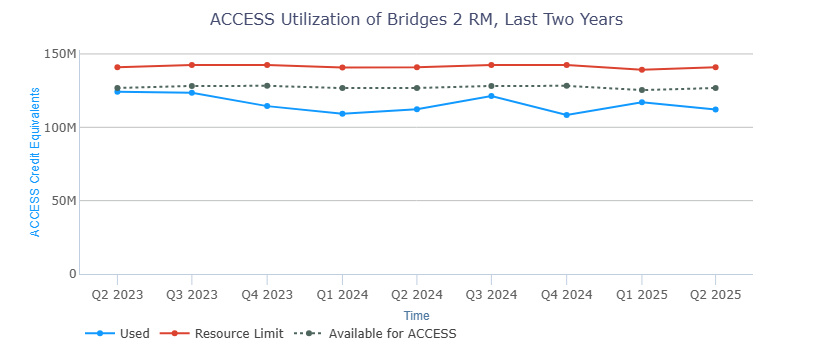

_Figure 2.1 Usage of Bridges 2 RM from 2023-04-01
    to 2025-06-30. Usage is shown converted to ACCESS Credit Equivalents. 
    The red solid line shows the hypothetical upper bound for credit usage based on the 
    number of compute elements on the resource. The green dotted line shows the mean value 
    of the ACCESS Credits that the resource is obliged to make available for use by ACCESS
    allocated jobs._
&nbsp;


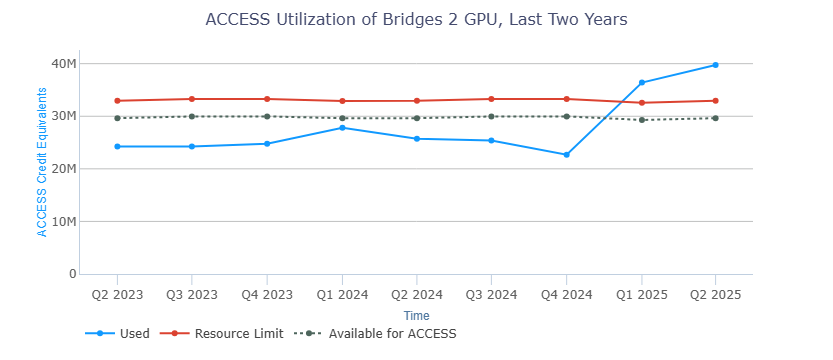

_Figure 2.2 Usage of Bridges 2 GPU from 2023-04-01
    to 2025-06-30. Usage is shown converted to ACCESS Credit Equivalents. 
    The red solid line shows the hypothetical upper bound for credit usage based on the 
    number of compute elements on the resource. The green dotted line shows the mean value 
    of the ACCESS Credits that the resource is obliged to make available for use by ACCESS
    allocated jobs._
&nbsp;


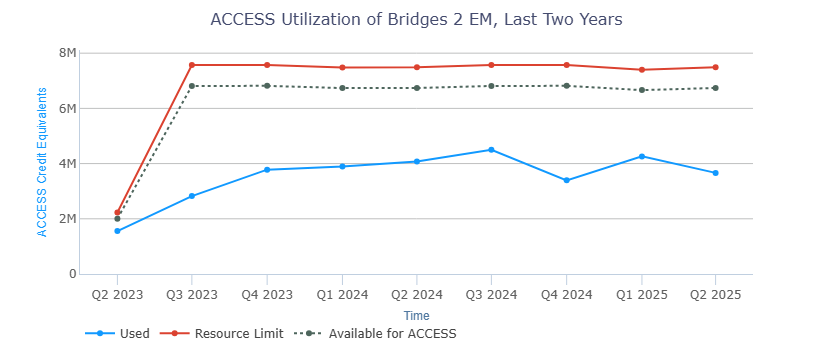

_Figure 2.3 Usage of Bridges 2 EM from 2023-04-01
    to 2025-06-30. Usage is shown converted to ACCESS Credit Equivalents. 
    The red solid line shows the hypothetical upper bound for credit usage based on the 
    number of compute elements on the resource. The green dotted line shows the mean value 
    of the ACCESS Credits that the resource is obliged to make available for use by ACCESS
    allocated jobs._
&nbsp;


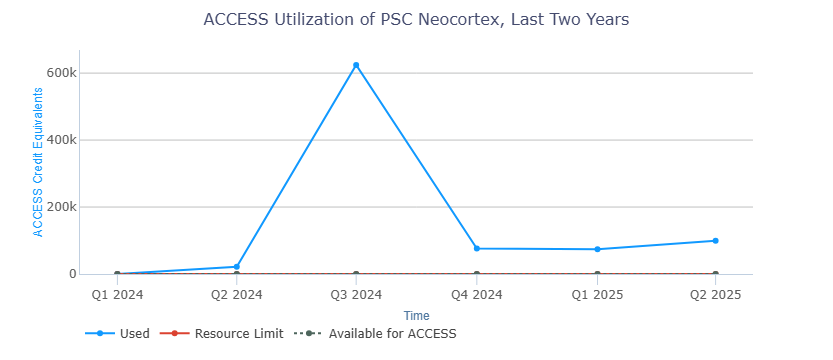

_Figure 2.4 Usage of PSC Neocortex from 2023-04-01
    to 2025-06-30. Usage is shown converted to ACCESS Credit Equivalents. 
    The red solid line shows the hypothetical upper bound for credit usage based on the 
    number of compute elements on the resource. The green dotted line shows the mean value 
    of the ACCESS Credits that the resource is obliged to make available for use by ACCESS
    allocated jobs._
&nbsp;


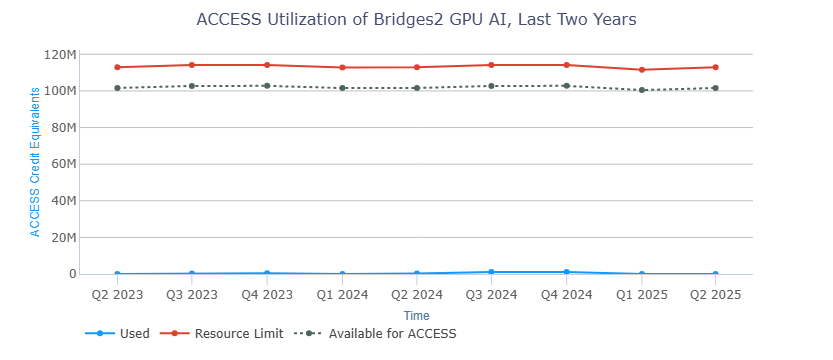

_Figure 2.5 Usage of Bridges2 GPU AI from 2023-04-01
    to 2025-06-30. Usage is shown converted to ACCESS Credit Equivalents. 
    The red solid line shows the hypothetical upper bound for credit usage based on the 
    number of compute elements on the resource. The green dotted line shows the mean value 
    of the ACCESS Credits that the resource is obliged to make available for use by ACCESS
    allocated jobs._
&nbsp;


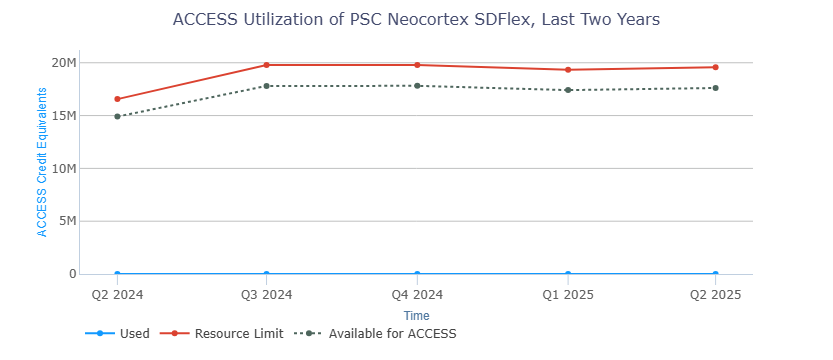

_Figure 2.6 Usage of PSC Neocortex SDFlex from 2023-04-01
    to 2025-06-30. Usage is shown converted to ACCESS Credit Equivalents. 
    The red solid line shows the hypothetical upper bound for credit usage based on the 
    number of compute elements on the resource. The green dotted line shows the mean value 
    of the ACCESS Credits that the resource is obliged to make available for use by ACCESS
    allocated jobs._
&nbsp;


In [26]:
# Information about Resource Utilization

display(section_title('Resource Utilization'))

if len(RESOURCES['Jobs']):
    display(Markdown("""
This section shows utilization information for ACCESS-allocated compute resources. 
To faciliate comparison across different types of compute resources (such as CPU or GPU),
usage is presented in ACCESS Credit Equivalents. Each compute resource has a conversion
factor between a resource service unit and an ACCESS Credit. For example, one ACCESS Credit
Equivalent is equal to 1 CPU core hour on SDSC Expanse (which uses AMD EPYC 7742 processors).
    
The data here are based on information reported to ACCESS by the RP via the Usage Reporting API.
    """))

    for resource in RESOURCES['Jobs']:
        plot_jobs_utilization(resource)

if len(RESOURCES['Cloud']):
    display(Markdown("""
This section shows utilization information for ACCESS-allocated Cloud resources. 

The data here are based on OpenStack log records reported to ACCESS Metrics.
"""))

    for resource in RESOURCES['Cloud']:
        plot_cloud_utilization(resource)

# 3. Active Projects


This section shows information about ACCESS projects running on the resources. A project
is counted as active in a time period if there was resource usage charged to
the project. Projects that had an allocation on the resource but no usage are not
included in these data.



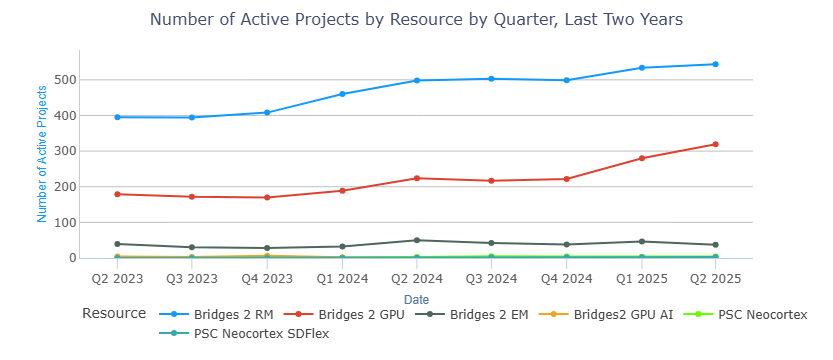

_Figure 3.1 Number of Active Projects by Resource by Quarter, Last Two Years._
&nbsp;



### By Parent Field of Science
This section shows the breakdown of active projects by the parent field of science of the
project. The field of science information is provided by the project's PI when they
apply for or update their project information. The parent field of science shown
in this data is obtained from each project's primary field of science.


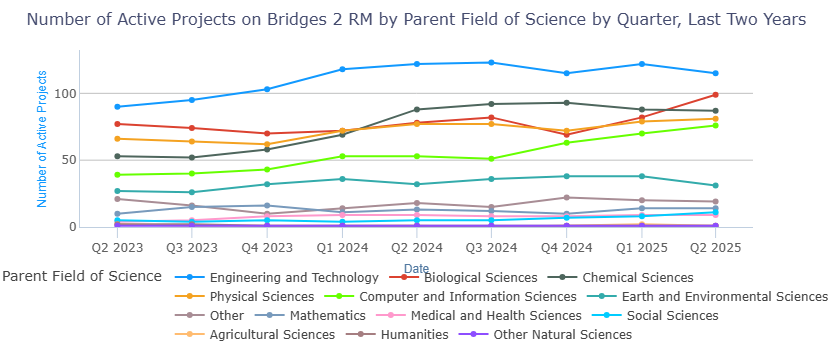

_Figure 3.2 Number of Active Projects on Bridges 2 RM by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


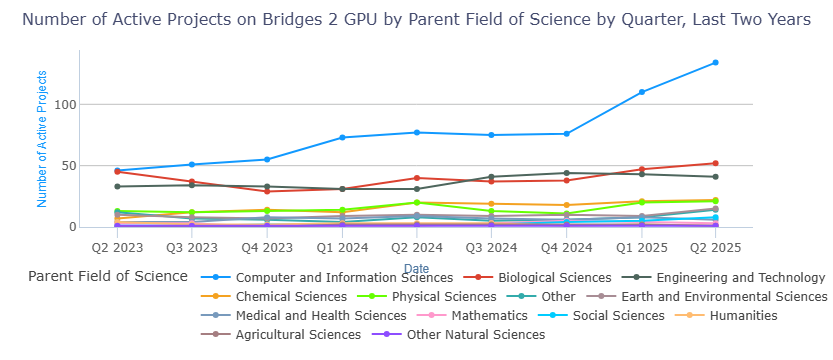

_Figure 3.3 Number of Active Projects on Bridges 2 GPU by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


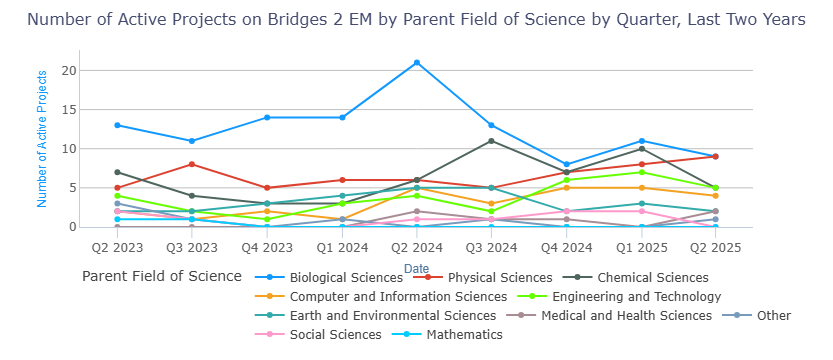

_Figure 3.4 Number of Active Projects on Bridges 2 EM by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


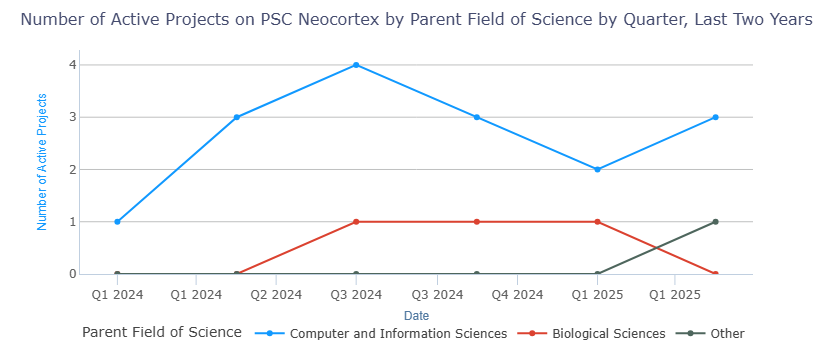

_Figure 3.5 Number of Active Projects on PSC Neocortex by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


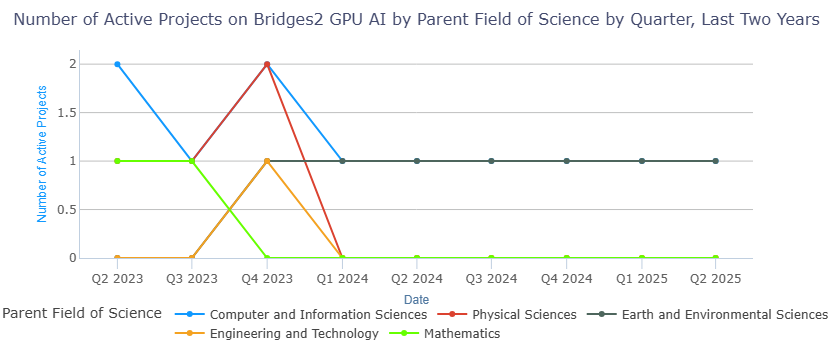

_Figure 3.6 Number of Active Projects on Bridges2 GPU AI by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


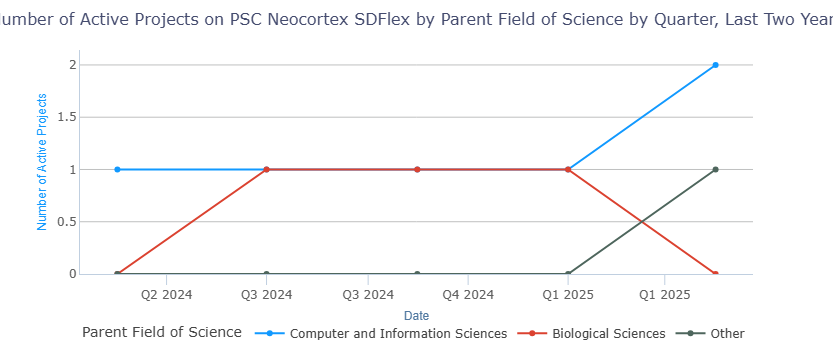

_Figure 3.7 Number of Active Projects on PSC Neocortex SDFlex by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


In [27]:
# Information about active projects

display(section_title('Active Projects'))

display(Markdown("""
This section shows information about ACCESS projects running on the resources. A project
is counted as active in a time period if there was resource usage charged to
the project. Projects that had an allocation on the resource but no usage are not
included in these data.

"""))

two_year_line_plot_by_resource(
    jobs_metric='Number of Allocations: Active',
    cloud_dimension='Allocation',
    y='Number of Active Projects',
)

display(Markdown("""
### By Parent Field of Science
This section shows the breakdown of active projects by the parent field of science of the
project. The field of science information is provided by the project's PI when they
apply for or update their project information. The parent field of science shown
in this data is obtained from each project's primary field of science.
"""))

if len(RESOURCES['Jobs']) > 0:
    for resource in RESOURCES['Jobs']:
        two_year_line_plot_by_quarter(
            y='projects',
            resource=resource,
            dimension='pfos',
        )
        
if len(RESOURCES['Cloud']) > 0:
    display(HTML('<div class="notes"><p>Field of Science information for Cloud resources is not available the current release of ACCESS XDMoD. These data will be available in the next release of ACCESS XDMoD.</p></div>'))

### By Type

In [ ]:
plot_num_projects_by_type('Purdue Anvil GPU')
plot_num_projects_by_type('Purdue Anvil CPU')

### Some Projects started as one type but later changed to a different type

In [ ]:
resource = 'Purdue Anvil CPU'
format_str = '%Y-%m-%d'
day_before_two_years_ago_quarter_start_date = (datetime.strptime(TWO_YEARS_AGO_QUARTER_START_DATE, format_str).date() - timedelta(days=1)).strftime(format_str)


with dw:
    active_project1 = dw.get_data(
         realm = 'Jobs',
         duration = ('2015-01-01' , day_before_two_years_ago_quarter_start_date),
         metric = 'Number of Jobs Running', 
         dimension = 'Allocation',
         dataset_type = 'aggregate',
         aggregation_unit='quarter',
         filters = {'Resource': resource},
     )

    active_project2 = dw.get_data(
        realm = 'Jobs',
        duration = (TWO_YEARS_AGO_QUARTER_START_DATE , QUARTER_END_DATE),
        metric = 'Number of Jobs Running', 
        dimension = 'Allocation',
        dataset_type = 'timeseries',
        aggregation_unit='quarter',
        filters = {'Resource': resource},
    )
    
old_projects = active_project1.index.tolist()

active_project2 = active_project2.transpose()
active_project2 = active_project2.reset_index()

active_project2 = active_project2[~active_project2['Allocation'].isin(old_projects)]



num_per_quarter = []
list_of_quarters = active_project2.columns[1:].to_list()

for quarter in list_of_quarters:

    active_rows = active_project2[active_project2[quarter] > 0]
    num_per_quarter.append(len(active_rows))
    active_project2 = active_project2.drop(active_rows.index)


plot = px.line(
    x= list_of_quarters, 
    y= num_per_quarter ,
    
    title="Number of new active projects per quarter in the Last 2 years",
    
)
plot.update_traces(
    hovertemplate='%{y:,.0f}',
    )
plot.update_layout(
    xaxis_tickformat='Q%q %Y',
    hovermode='x unified',
    hoverlabel_namelength=-1,
    )


plot.update_xaxes(title_text='Last 2 years in Quarters')
plot.update_yaxes(title_text='Number of Active Projects')

plot.show()


### Interactive table for projects

In [ ]:
resources = ['Purdue Anvil CPU', 'Purdue Anvil GPU']

with dw:
    for resource in resources:
        
        df_ace_charged = dw.get_data(
            duration = (QUARTER_START_DATE, QUARTER_END_DATE),
            realm = 'Jobs',
            metric = 'ACCESS Credit Equivalents Charged: Total (SU)',
            dimension = 'Allocation',
            dataset_type = 'aggregate',
            filters = {'Resource': resource},
        )
        
        df_jobs_ran = dw.get_data(
            duration = (QUARTER_START_DATE, QUARTER_END_DATE),
            realm = 'Jobs',
            metric = 'Number of Jobs Running',
            dimension ='Allocation',
            dataset_type ='aggregate',
            filters = {'Resource': resource},
        )
        
        df_all_projects = dw.get_raw_data(
                   duration = (QUARTER_START_DATE,QUARTER_END_DATE),
                   realm = 'Allocations',
                   filters = {'Resource': resource}
        )
        
        active_projects = df_ace_charged.index.tolist()
        
        
        df_active_projects = df_all_projects[df_all_projects['Name'].isin(active_projects)]
        df_active_projects = df_active_projects[['Name', 'Initial Start Date', 'Board Type','Field of Science','Parent Science']]
        df_active_projects = df_active_projects.rename(columns={
            'Board Type': 'Type',
            'Name': 'Title'
        })
        df_active_projects = df_active_projects.sort_values(by='Initial Start Date')
        
        df_active_projects = df_active_projects.groupby(
            ['Title','Field of Science','Parent Science']
        ).agg(
            {'Type': lambda x: ' -> '.join(list(dict.fromkeys(x)))
            }
        )
        
        
        df_active_projects = df_active_projects.reset_index().set_index('Title')
        
        df_active_projects = df_active_projects.join(df_ace_charged)
        df_active_projects = df_active_projects.join(df_jobs_ran)
        
        
        df_active_projects = df_active_projects.rename(columns={
            'Number of Jobs Running':'Number of Jobs',
            'ACCESS Credit Equivalents Charged: Total (SU)':'ACCESS Credit Equivalents Charged'
        })
        
        df_active_projects = df_active_projects.reset_index()
        
        
        df_active_projects[['Charge Number', 'Title']] = df_active_projects['Title'].str.split('-', n=1, expand=True)
        df_active_projects = df_active_projects.set_index('Charge Number')

        

        reorder_columns = ['ACCESS Credit Equivalents Charged',
                           'Number of Jobs',
                           'Type',
                           'Parent Science',
                           'Field of Science',
                           'Title'
                          ]
        df_active_projects = df_active_projects[reorder_columns]

        df_active_projects = df_active_projects.reset_index()

        title = 'ACCESS-Metrics-Report-' + resource.replace(' ', '-') + '-2025-Q1-Projects'

        css = """
        table.dataTable th.dt-type-numeric div.dt-column-header {
            flex-direction: row !important;
        }
        table.dataTable tfoot>tr>th div.dt-column-footer span.dt-column-title input {
            width: 100%
        }
        """
        display(HTML(f'<style>{css}</style>' ''))


        js_code = """
        $.fn.dataTable.ext.type.order['project-type-pre'] = function ( data ) {
  
            access_project_types = ['Explore', 'Discover', 'Accelerate', 'Maximize'];
            custom_sort_order = {};
            rank = 0;
            for (i = 0; i < access_project_types.length; i++) {
                custom_sort_order[access_project_types[i]] = rank++;
                if (i + 1 < access_project_types.length) {
                    custom_sort_order[access_project_types[i] + ' -> ' + access_project_types[i + 1]] = rank++;
                }
            }
          return custom_sort_order[data]; 
        };"""
        
        display(Javascript(js_code))

        itables.options.text_in_header_can_be_selected = False

        order = []

        itables.show(
            df_active_projects,
            buttons=[
                'pageLength', 'copyHtml5',
                {"extend": "csvHtml5", "title": title},
                {"extend": "excelHtml5", "title": title},
                "columnsToggle",
            ],
            column_filters= 'footer',
            order=[[1, 'desc']],
            autoWidth=False,
            allow_html=True,
            columnDefs=[{
            "targets": [1],
            "render": itables.JavascriptCode(
                "$.fn.dataTable.render.number(',' , '.' , '2')"
            ),},{"targets": [2],
                 "render": itables.JavascriptCode("$.fn.dataTable.render.number(',', '.',)")
                },{'width': '1px','className': 'dt-left','orderSequence': ['asc', 'desc'] , 'targets': '_all',},
                        {"className": "dt-body-right",'orderSequence': ['desc', 'asc'], "targets": [1, 2]},
                       ])


# 4. Active Users


This section shows information about active users. The active
user metrics are based on the batch job or virtual machine owners. These metrics
do not include counts of people who were indirectly associated with
the compute usage such as science gateway end-users or users
interacting with web services run inside VMs.


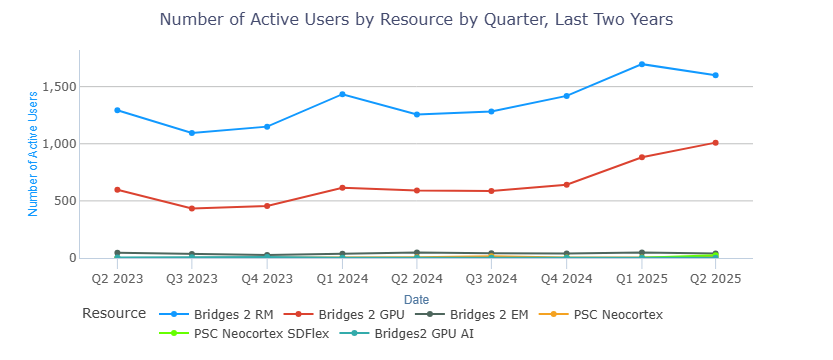

_Figure 4.1 Number of Active Users by Resource by Quarter, Last Two Years._
&nbsp;



### By Parent Field of Science
This section shows the counts of users by the parent field of science of the
ACCESS project that was charged.


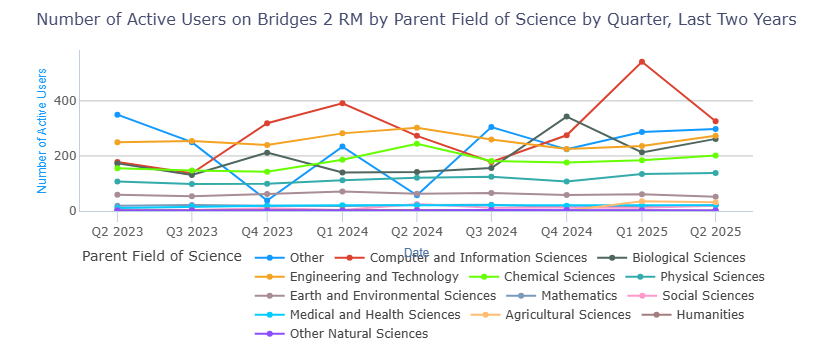

_Figure 4.2 Number of Active Users on Bridges 2 RM by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


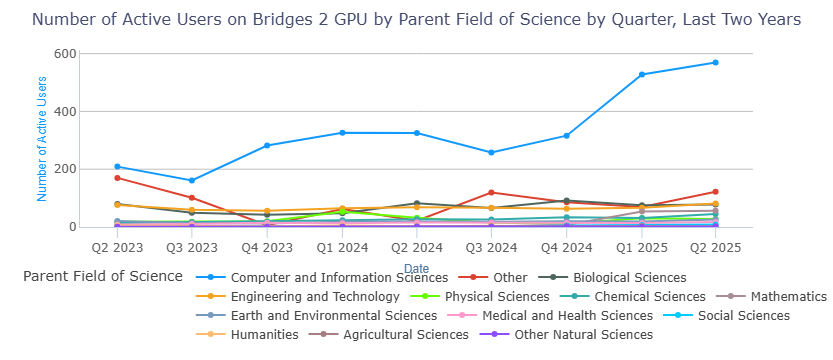

_Figure 4.3 Number of Active Users on Bridges 2 GPU by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


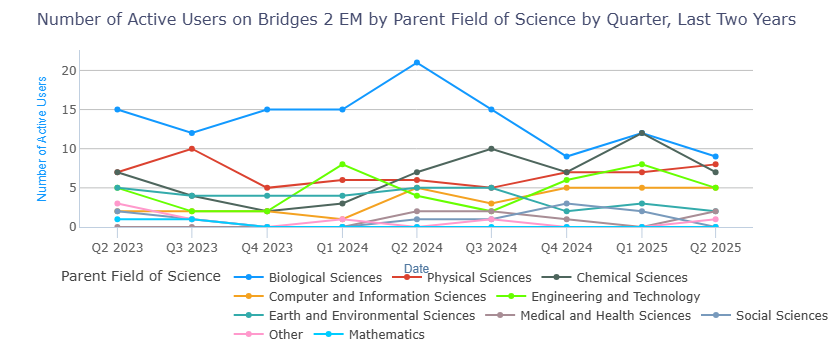

_Figure 4.4 Number of Active Users on Bridges 2 EM by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


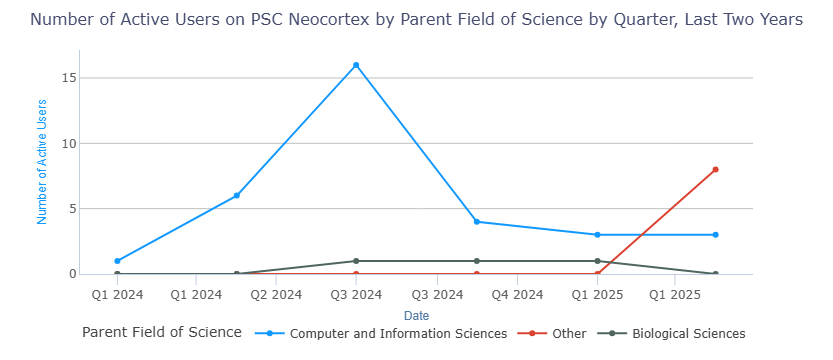

_Figure 4.5 Number of Active Users on PSC Neocortex by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


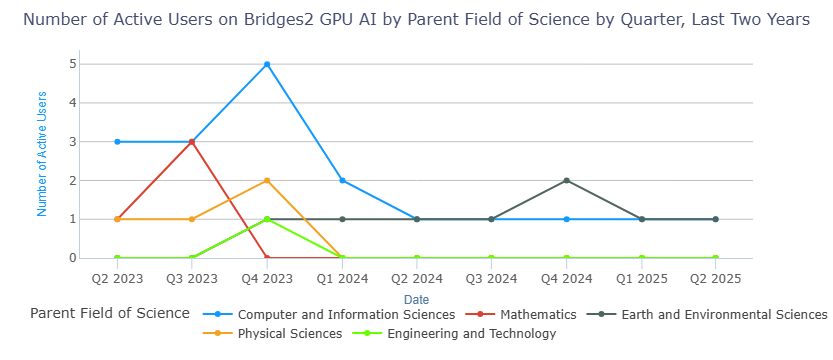

_Figure 4.6 Number of Active Users on Bridges2 GPU AI by Parent Field of Science by Quarter, Last Two Years._
&nbsp;


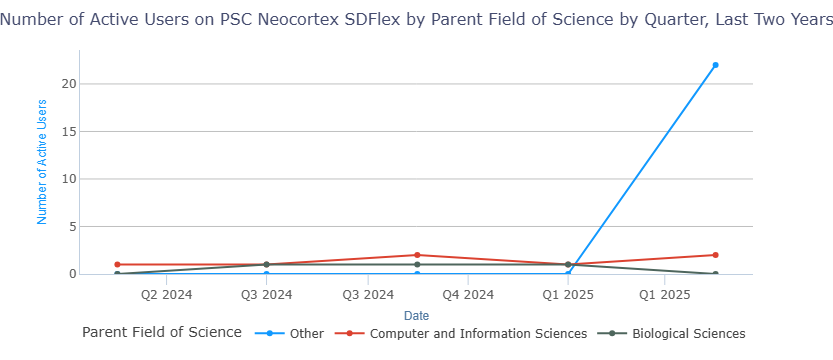

_Figure 4.7 Number of Active Users on PSC Neocortex SDFlex by Parent Field of Science by Quarter, Last Two Years._
&nbsp;



### By Academic Status
This section shows the counts of users by the Academic Status value
from their ACCESS profile. This value is self reported by users when
they first register for an ACCESS account. A value of Unknown means that
they did not complete their profile information.


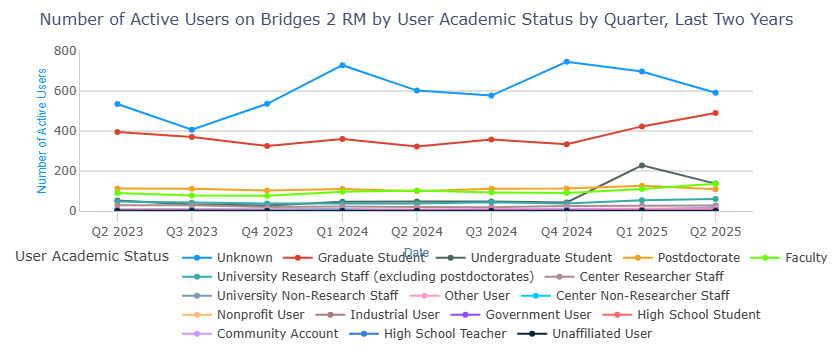

_Figure 4.8 Number of Active Users on Bridges 2 RM by User Academic Status by Quarter, Last Two Years._
&nbsp;


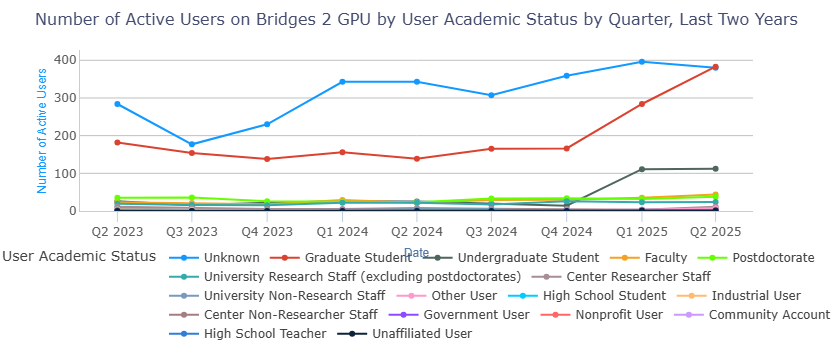

_Figure 4.9 Number of Active Users on Bridges 2 GPU by User Academic Status by Quarter, Last Two Years._
&nbsp;


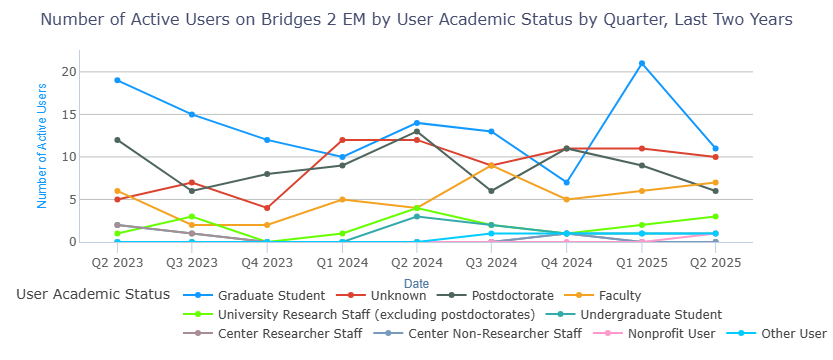

_Figure 4.10 Number of Active Users on Bridges 2 EM by User Academic Status by Quarter, Last Two Years._
&nbsp;


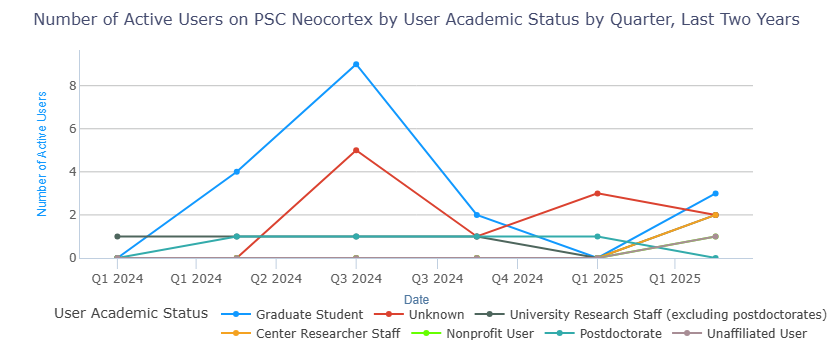

_Figure 4.11 Number of Active Users on PSC Neocortex by User Academic Status by Quarter, Last Two Years._
&nbsp;


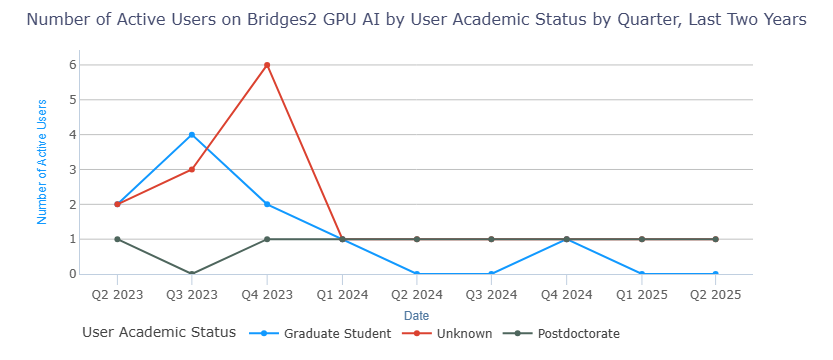

_Figure 4.12 Number of Active Users on Bridges2 GPU AI by User Academic Status by Quarter, Last Two Years._
&nbsp;


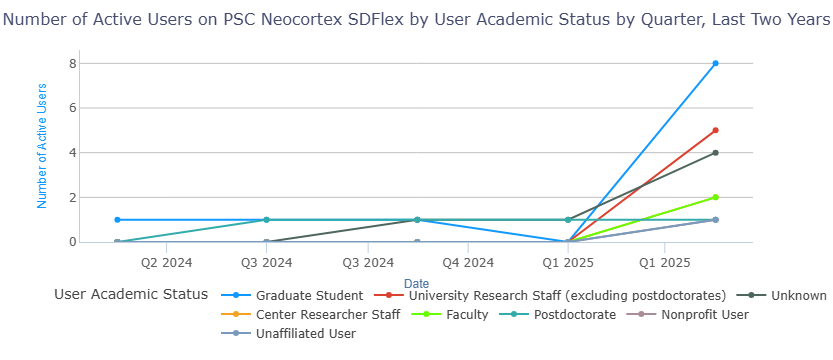

_Figure 4.13 Number of Active Users on PSC Neocortex SDFlex by User Academic Status by Quarter, Last Two Years._
&nbsp;


In [28]:
# Information about active users

display(section_title('Active Users'))

display(Markdown("""
This section shows information about active users. The active
user metrics are based on the batch job or virtual machine owners. These metrics
do not include counts of people who were indirectly associated with
the compute usage such as science gateway end-users or users
interacting with web services run inside VMs.
"""))

two_year_line_plot_by_resource(
    jobs_metric='Number of Users: Active',
    cloud_dimension='User',
    y='Number of Active Users',
)

display(Markdown("""
### By Parent Field of Science
This section shows the counts of users by the parent field of science of the
ACCESS project that was charged.
"""))

for resource in RESOURCES['Jobs']:
    two_year_line_plot_by_quarter(
        y='users',
        resource=resource,
        dimension='pfos',
    )
if len(RESOURCES['Cloud']) > 0:
    display(HTML('<div class="notes"><p>Field of Science information for Cloud resources is not available the current release of ACCESS XDMoD. These data will be available in the next release of ACCESS XDMoD.</p></div>'))

display(Markdown("""
### By Academic Status
This section shows the counts of users by the Academic Status value
from their ACCESS profile. This value is self reported by users when
they first register for an ACCESS account. A value of Unknown means that
they did not complete their profile information.
"""))

for resource in RESOURCES['Jobs']:
    two_year_line_plot_by_quarter(
        y='users',
        resource=resource,
        dimension='academic status',
    )

if len(RESOURCES['Cloud']) > 0:
    display(HTML('<div class="notes"><p>User Adacemic Status information for Cloud resources is not available the current release of ACCESS XDMoD. These data will be available in the next release of ACCESS XDMoD.</p></div>'))

## User Institution with Bubble plot

### By Active User Count

In [ ]:
df = pd.read_csv('~/Downloads/xdmod-notebooks/user-inst-2025-q1.csv')
df.head()

df = df[df['total_ace'] != 0]

fig = go.Figure(data=go.Scattergeo(
    locationmode = 'USA-states',
    lon = df['longitude'],
    lat = df['latitude'],
    text = df['User Institution Name'],
    customdata=df['active_person_count'].values,
    hovertemplate="<b>User Institution</b>: %{text}<br><b>Number of Users Active</b>: %{customdata}<br><extra></extra>",
    mode = 'markers',
    marker = dict(
        size = df['active_person_count'], 
        color = 'blue',
        line_width = 0.5,
        sizemode = 'area'
    )))

fig.update_layout(
    title_text = 'User Institution in the U.S. by Active User count',
    showlegend = True,
    geo = dict(
        scope = 'usa',
        landcolor = 'rgb(217, 217, 217)'
    )
)
fig.update_layout(showlegend=False)

fig.show()

In [ ]:
## By Total ACE

In [ ]:


fig = go.Figure(data=go.Scattergeo(
    locationmode = 'USA-states',
    lon = df['longitude'],
    lat = df['latitude'],
    text = df['User Institution Name'],
    customdata=df['total_ace'].values,
    hovertemplate="<b>User Institution</b>: %{text}<br><b>Total Ace</b>: %{customdata}<br><extra></extra>",
    mode = 'markers',
    marker = dict(
        size = df['total_ace']/100000, # had to divide by 100,000 or this would fill the whole map in red
        color = 'red',
        line_width = 0.5,
        sizemode = 'area'
    )))

fig.update_layout(
    title_text = 'User Institution in the U.S. by Total ACE',
    showlegend = True,
    geo = dict(
        scope = 'usa',
        landcolor = 'rgb(217, 217, 217)'
    )
)

fig.update_layout(showlegend=False)


fig.show()

### By Running Job Count 

In [71]:
fig = go.Figure(data=go.Scattergeo(
    locationmode = 'USA-states',
    lon = df['longitude'],
    lat = df['latitude'],
    text = df['User Institution Name'],
    customdata=df['running_job_count'].values,
    hovertemplate="<b>User Institution</b>: %{text}<br><b>Running Job Count</b>: %{customdata}<br><extra></extra>",
    mode = 'markers',
    marker = dict(
        size = df['running_job_count'], 
        color = 'green',
        line_width = 0.5,
        sizemode = 'area'
    )))

fig.update_layout(
    title_text = 'User Institution in the U.S. by Running Job Count',
    showlegend = True,
    geo = dict(
        scope = 'usa',
        landcolor = 'rgb(217, 217, 217)'
    )
)

fig.update_layout(showlegend=False)


fig.show()

NameError: name 'go' is not defined

In [29]:
# Information about Open OnDemand usage

display(section_title('Open OnDemand Usage'))

display(Markdown("""
This section shows information about the usage of Open OnDemand obtained from
web server logs sent directly to the ACCESS Metrics team from the RP. A user is
counted as using Open OnDemand if they have logged into Open OnDemand on a resource
and they have an ACCESS affiliated account on the resource.
"""))


ondemand_usage_df = get_ondemand_usage()
if ondemand_usage_df is not None:
    two_year_line_plot_melt_and_plot(ondemand_usage_df, 'Number of Open OnDemand Users')
else:
    display(HTML(f'''
<div class="warn">Open OnDemand usage not available for resources from {PROVIDER}.</div>
'''))

# 5. Open OnDemand Usage


This section shows information about the usage of Open OnDemand obtained from
web server logs sent directly to the ACCESS Metrics team from the RP. A user is
counted as using Open OnDemand if they have logged into Open OnDemand on a resource
and they have an ACCESS affiliated account on the resource.


# 6. Science Gateway Usage


This section shows information about compute usage via Science Gateways
that have a compute allocation and a community account.
These data come from the information reported by ACCESS integrated
Science Gateways via the [reporting API](https://readthedocs.access-ci.org/projects/integration-roadmaps/en/latest/tasks/Science_Gateway_Usage_Reporting_v1.html).
Not all gateways use the API, so the user counts
represent a lower bound of the total number of people who are
making use of compute via a gateway.


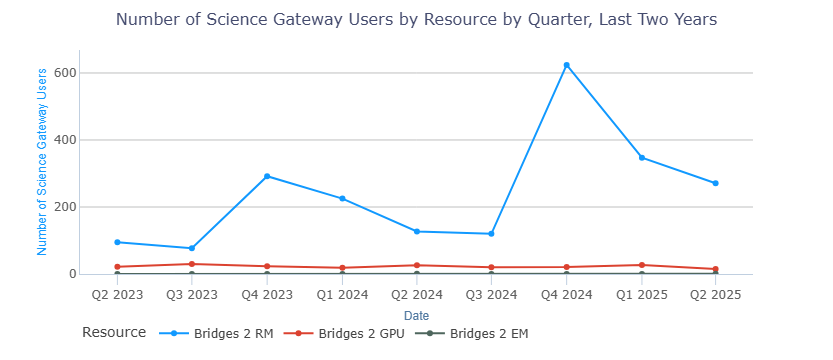

_Figure 6.1 Number of Science Gateway Users by Resource by Quarter, Last Two Years._
&nbsp;


In [30]:
# Information about science gateways

display(section_title('Science Gateway Usage'))

display(Markdown("""
This section shows information about compute usage via Science Gateways
that have a compute allocation and a community account.
These data come from the information reported by ACCESS integrated
Science Gateways via the [reporting API](https://readthedocs.access-ci.org/projects/integration-roadmaps/en/latest/tasks/Science_Gateway_Usage_Reporting_v1.html).
Not all gateways use the API, so the user counts
represent a lower bound of the total number of people who are
making use of compute via a gateway.
"""))
science_gw_users_df = get_science_gateway_usage()
if science_gw_users_df is not None:
    two_year_line_plot_melt_and_plot(science_gw_users_df, 'Number of Science Gateway Users')
else:
    display(HTML(f'''
<div class="warn">Science Gateway usage not available for 
resources from {PROVIDER}.</div>
'''))

In [ ]:
# Network data
display(section_title('Network Flows'))
display(Markdown("""
Network flows and Globus Transfer information for ACCESS RPs
are tracked via [NetSage for ACCESS](https://access.netsage.io/).

<div class="notes">Embedded network usage data will be available in a future version of this report.</div>
"""))

In [ ]:
# Job Performance in XDMoD is only supported for batch compute resources
if len(RESOURCES['Jobs']) > 0:
    display(section_title('Job Performance'))
    display(Markdown(
'''
Job Efficiency data in ACCESS XDMoD are obtained from performance
data collected on the compute nodes combined with accounting information
from job scheduler logs and the ACCESS Usage API.

Additional data are available in the
[Efficiency tab](https://xdmod.access-ci.org/#main_tab_panel:efficiency)
in ACCESS XDMoD (some data may only be visible if you have the
Center Staff or Center Director role;
[submit a ticket](https://support.access-ci.org/help-ticket)
to the ACCESS Metrics team to request this role if you do not have it).
'''))
    resource_specs = get_resource_specs(RESOURCES['Jobs'])

    cpu_based = resource_specs.get('CPU Allocated', []) + resource_specs.get('CPU Node Allocated', [])
    if cpu_based:
        display(Markdown(f'### CPU Usage for CPU-based Compute Resources'))
        display(Markdown('''
This section shows CPU usage data for CPU-based compute resources.
The CPU User value is the ratio of CPU time elapsed where the operating system
is in user mode to total CPU time for the cores that the job was assigned.
'''))
 
    for resource in cpu_based:
        make_efficiency_plot(resource, 'CPU')
        make_performance_histogram(resource, 'CPU')

    gpu_based = resource_specs.get('GPU Allocated', []) + resource_specs.get('GPU Node Allocated', [])
    if gpu_based:
        display(Markdown(f'### GPU Usage for GPU-based Compute Resources'))
        display(Markdown('''
This section shows GPU usage data for GPU-based compute resources.
The GPU usage is the value reported by the GPU driver software running
on the compute nodes and indicates the proportion of time where the GPU
was executing instructions.
''')) 
    for resource in gpu_based:
        make_efficiency_plot(resource, 'GPU')
        make_performance_histogram(resource , 'GPU')


In [ ]:
resources = ['Purdue Anvil CPU', 'Purdue Anvil GPU']

for resource in resources:  
    
    with dw: 
        df = dw.get_data(
            realm = 'Jobs',
            duration = (TWO_YEARS_AGO_QUARTER_START_DATE , QUARTER_END_DATE),
            metric = 'ACCESS Credit Equivalents Charged: Total (SU)', 
            dimension = 'Allocation',
            dataset_type = 'timeseries',
            aggregation_unit='Day',
            filters = {'Resource': resource},
        )
        data = dw.get_raw_data(
            duration=(TWO_YEARS_AGO_QUARTER_START_DATE, QUARTER_END_DATE),
            realm='Allocations',
            #fields=(
                #'Name',
                #'Initial Start Date',
                #'ACCESS Credit Equivalents Allocated',
            #),
            filters = {'Resource': resource},
        )

    
   
    data = data.sort_values(by='Project Charge Number')
    data = data[data.duplicated(subset=['Project Charge Number'], keep=False)]

    
    
    data = data.sort_values(by='Name')
        
    df2 = df.ne(0).idxmax().to_frame('Date of First ACE Used')
    df2 = df2.reset_index()
    df2.rename(columns={'Allocation': 'Name'},inplace=True)

    
    data = data.groupby(['Name']).agg({'Initial Start Date': 'min'})
    
    merged_df = pd.merge(df2, data, on='Name', how='inner')

    
    
    merged_df[['Charge Number', 'Name']] = merged_df['Name'].str.split('-', n=1, expand=True)
    merged_df = merged_df.drop('Name', axis=1)
    columns_titles = ['Charge Number','Initial Start Date','Date of First ACE Used','ACCESS Credit Equivalents Allocated',]
    merged_df=merged_df.reindex(columns=columns_titles)
    
    
    
    display(merged_df)
    

In [ ]:

response = requests.get('https://operations-api.access-ci.org/wh2/news/v1/affiliation/access-ci.org/all_outages')
data = response.json()["results"]

rows = []
for outage in data:
    subject = outage.get("Subject")
    start = outage.get("OutageStart")
    end = outage.get("OutageEnd")
    
    for resource in outage.get("AffectedResources", []):
        resource_id = resource.get("ResourceID")
        rows.append({
            "ResourceID": resource_id,
            "Subject": subject,
            "OutageStart": start,
            "OutageEnd": end
        })

df = pd.DataFrame(rows)

display(df)

In [ ]:
footer(METADATA)